<a href="https://colab.research.google.com/github/gabrielabustamantealarcon/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- **Columnas con valores faltantes en users: city con 11.72% y churn_date con 88.35%.**
- **Columnas con valores faltantes en usage: date con 0.12%, duration con 55.19% y length con 44.74%.**
- Indica qué harías: ¿imputar, eliminar, ignorar?
- **Para la columna city de users, primero seria verificar si exixte relacion entre los nulos con otra columna, segun el porcentaje no es una cantidad significativa como para no ignorar, por lo que se podria imputar con la moda o marcar los vacios con alguna otra categoria, como desconocido("unknown"), en caso de no querer alterar los datos geograficos, para el caso de churn_date, se podria decidir eliminacion inmediata, pero al ser una variable de tiempo o de permanecia en este caso, serviria dejarla, pero con algun tipo de modificacion, puesto que los nulos o vacios en gran parte deben ser clientes que se mantienen activos.(Las demas columnas de users se observan sin nulos.)**
- **Para los valores faltantes de la columna date en usage, se puede eliminar directamente los nulos, para no afectar en las estadisticas, pues representa una perdida minima de datos, pero tambien se podria rellenar con la moda, dado que son escasos datos y no deberian afectar, para el caso de duration esta en el limite, pero se puede analizar en conjunto a otra columna como length para determinar relacion y posterior se debe decidir si rellenar con cero (0) o definitivamente eliminar y para length seria similar a duration al analizar ambas en conjunto se debe decidir.**

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: **Es una secuencia numerica limpia que va desde el 10.000 al 13.999, es un identificador, por tanto las metricas no representan la realidad, solo se confirma que se mantiene completa con 4.000 usuarios.**
- La columna `age`: **Se observa un valor -999, el cual esta alterando evidentemente la media y std, por cual se distancia de la moda o percentil 50%.**

In [ ]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: **Se observan con rangos correctos como identificador, en estos casos metricas no tienen sentido.**
- Las columnas **'duration' y 'length': Se observan como complemento, puesto que al sumar count de ambas, el valor es similar al total, por tanto los nulos de ambas son el complemento de la otra, pero se puede destacar en duration una direfencia entre media y mediana con una distribucion sesgada a la derecha por un valor alto como 120, que se podria considerar error o solo una llamada extensa, algo no menor pasa en length donde se observa que el percentil 75% llega a 64, pero el maximo es 1490, un valor extremo.**

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print(users[col].value_counts())
    print()


city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city`: **Se observan datos completos, pero un valor "?" con 96 registros, ademas de dirente formato en el registro de las ciudades.**
- La columna `plan`:**Se observan solo dos categorias basico y premium, practicamente limpio.**

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`:**Se observan dos categorias text y call, sumadas dan el total de los casos, por tanto confirma nulos anteriores no son errores.**


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- **Valores invalidos en age con "-999", en duration "120", en length "1.490", en city "?".**
- ¿Qué acción tomarías?
- **En el caso de age, se pueden sustituir por la mediana o la media real post corregido el error.**
- **En el caso de duration, considerar si mantener porque 120 es un numero alto, pero posible.**
- **En el caso de length, graficar un boxplot para verificar real distribucion de los datos y en especifico de los outliers, posterior se podria consirerar winsorizacion o eliminacion directa de los datos**
- **En el caso de city, se podria imputar por la moda que en este caso es Bogota, o definitivamente marcar como desconocido para no alterar distribucion geografica.**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'])
print(users['reg_date'].dt.year.value_counts().sort_index())

0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`:**Se observan registros desde el 2022 hasta 2024, ademas de 2026 lo cual no es posible.**

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'])
print(usage['date'].dt.year.value_counts().sort_index())

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]
2024.0    39950
Name: date, dtype: int64


En `date`:**Se observan solo registros del año 2024.**
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- **Se observa en users fechas desde el año 2022 hasta 2024, pero aparecen usuarios de 2026 fecha que no pertenece al data, en cambio en usage solo se observa 2024.**
- ¿Qué harías con ellas?
- **Crear nuevas columnas como "year" y "month", ademas de eliminar fechas no consideradas en el data por ejemplo 2026.**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print(users['city'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:

fechas_invalidas = users['reg_date'].dt.year > 2024

# Asignar pd.NA a las fechas inválidas

users.loc[fechas_invalidas, 'reg_date'] = pd.NaT

# Verificar cambios

print(users['reg_date'].dt.year.value_counts().sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
**Segun lo observado se puede confirmar que los valores nulos en las columnas duration y length son del tipo MAR, pues el analisis muestra coasi un 100% en la ausencia de datos segun la variable type, se puede concluir que las llamadas carecen de longitud de caracteres y que los mensajes no tiene duracion, por tanto se deben mantener los datos tal cual, puesto que no es un error de registro, si no que mantienen una logica.**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

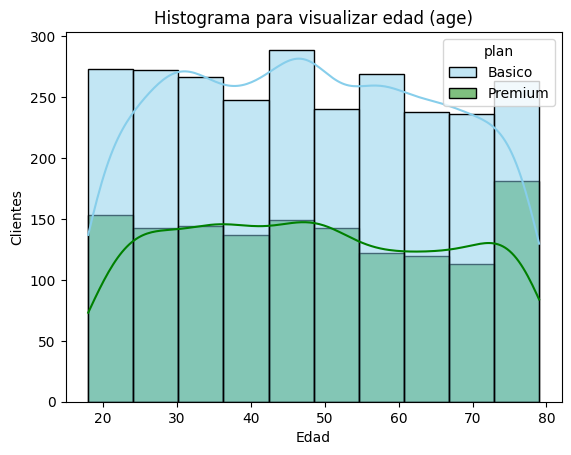

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", bins=10, palette=['skyblue','green'], kde=True)
plt.title ("Histograma para visualizar edad (age)")
plt.xlabel("Edad")
plt.ylabel("Clientes")
plt.show()

💡Insights:
- Distribución: **Se observa que el plan basico tiende a duplicar en volumen al plan premium, en todas las edades, se puede concluir ademas que ambos planes muestran una distribucion uniforme sin dominantes marcados, pero significativamente el plan basico sostenido superior en todas las edades es lo mas destacable.**

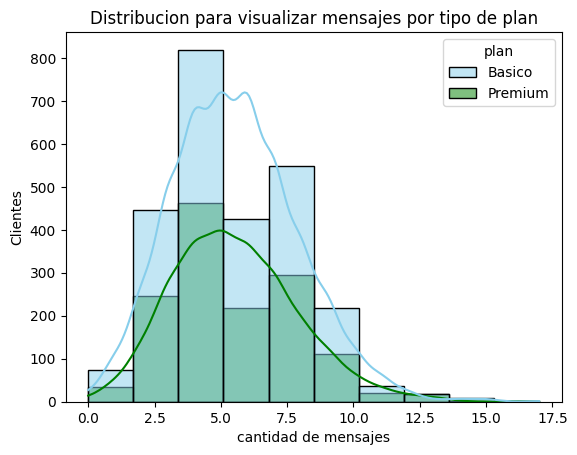

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=10, palette=['skyblue','green'], kde=True)
plt.title ("Distribucion para visualizar mensajes por tipo de plan")
plt.xlabel("cantidad de mensajes")
plt.ylabel("Clientes")
plt.show()

💡Insights:
- **Se observa una distribucion sesgada a la derecha, puesto que la mayoria de los usuarios envia 2.5 a 7.5, independientemente del plan, en general se visualiza que el plan basico tiene un uso mas estandarizado, pero en cambio el premium tiene una mayor variabilidad, en cuanto a la cantidad en mensajes superior a 10, puesto que presenta una ligera cola mas larga hacia la derecha.**

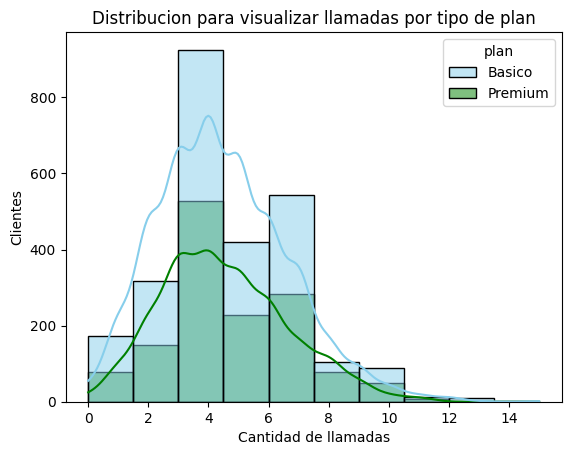

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=10, palette=['skyblue','green'], kde=True)
plt.title ("Distribucion para visualizar llamadas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Clientes")
plt.show()

💡Insights:
- Distribución: **Se observa una distribucion sesgada a la derecha, pero con dos picos destacables, en ambos planes, en cuanto al plan basico presenta una marcada caida post 7 llamadas, en cuanto al plan premium presenta una estabilidad o aplanada a lo largo, se puede concluir que la presencia de un segundo pico mas alejado de la media, se podria tomar como usarios de posible transicion.**

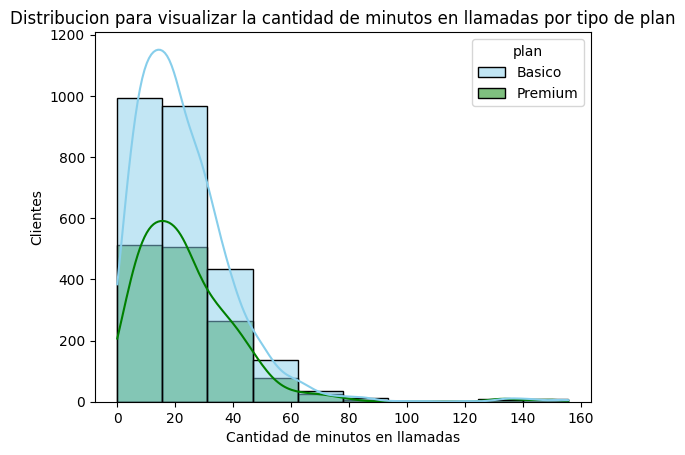

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", bins=10, palette=['skyblue','green'], kde=True)
plt.title ("Distribucion para visualizar la cantidad de minutos en llamadas por tipo de plan")
plt.xlabel("Cantidad de minutos en llamadas")
plt.ylabel("Clientes")
plt.show()

💡Insights:
- **Se observa una ditrubucion sesgada a la derecha, presentando una concentracion destacada en ambos planes en el primer intervalo 0 a 20 minutos, pero existe una diferencia entre ambos planes, puesto que el plan basico presenta un pico mas alto y marcado, el plan premium presenta una curva mas ancha, dejando la posibilidad de realizar llamadas mas largas, se puede concluir que las llamadas del plan basico se centran en llamadas cortas, mentras que el plan premium, presenta una mayor variedad, presentando cierta orientacion a llamadas un tanto mas prolongadas, pero ademas revisar llamadas largas en plan basico**

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

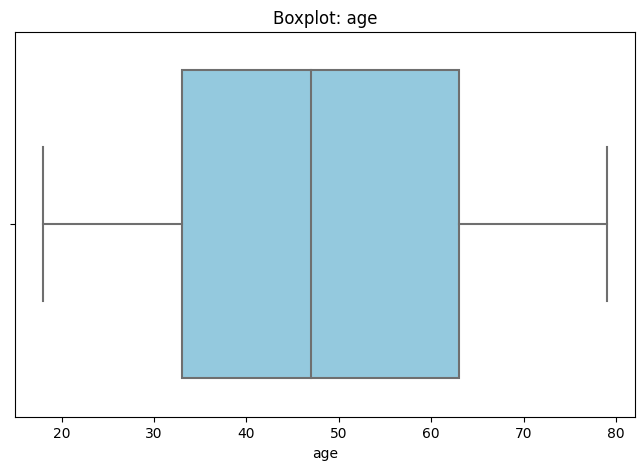

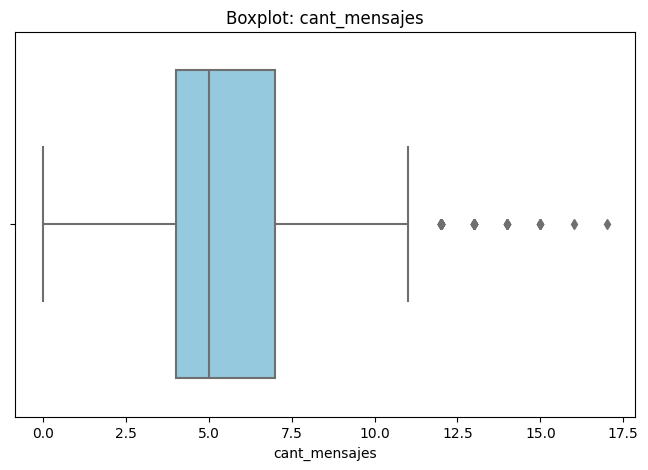

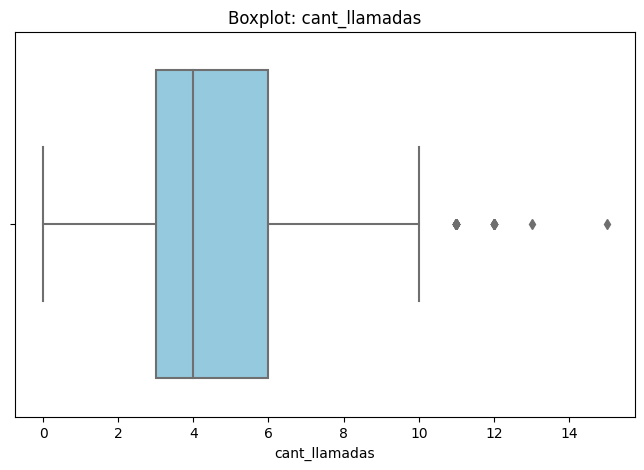

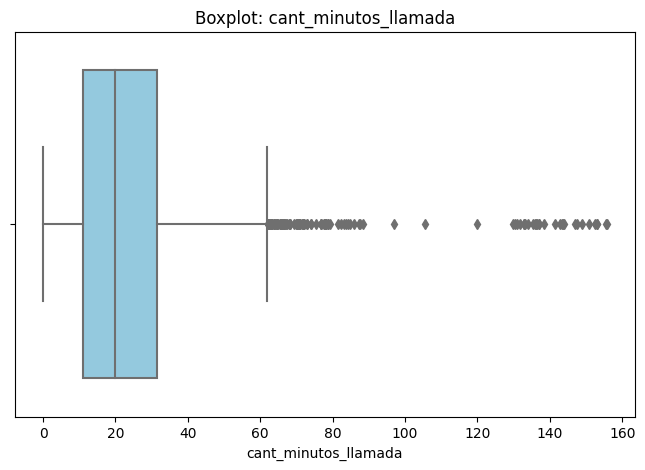

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=user_profile[col], color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show


💡Insights:
- Age:**Se observa una distribucion simetrica, sin presencia de outliers, por tanto toda posible estrategia en marketing afectaria al 100% de la muestra, ademas de presentar un adulto medio como mediana, receptivo a planes de fidelidad por ejemplo.**
- cant_mensajes: **Se observa presencia de outliers, por tanto una asimetria, lo cual demuestra un mayor consumo de mensajes, pero no tan alejados de la realidad, por tanto no deberian ser eliminados, sino analizados, puesto que si esos clientes que presentan cantidad de mensajes elevados son candidatos a posibles campañas como la de "Suma a un amigo" o algo similar.**
- cant_llamadas: **Se observa presencia de outliers, por lo que se presenta una asimetria, lo cual demuestra a clientes con mayor cantidad de llamadas, por tanto no deberian eliminarse, sino analizar y ofrecer un mejor plan a ciertos grupos con alta necesidad ante de una fuga a otro prestador.**
- cant_minutos_llamada: **Se observa presencia de outliers, por lo que es asimetrico, se puede concluir que la mayoria de los usuarios solo mantienen llamadas de 30 minutos, pero en cambio existe un grupo que supera hasta los 100 minutos, por tanto un posible desafio y oportunidad comercial, puesto que podrian ser usuarios que migren al encontrar mejor alternativas en cuanto a duracion de llamadas.**
- **Como conclusion final: la presencia de outliers en llamadas y mensajes, reflejan una oportunidad en cuanto a cambio de planes desde basico a premium.**

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"Columna: {col}")
    print(f"Primer Cuartil: {Q1}")
    print(f"Tercer Cuartil: {Q3}")
    print(f"IQR: {IQR}")
print()

Columna: cant_mensajes
Primer Cuartil: 4.0
Tercer Cuartil: 7.0
IQR: 3.0
Columna: cant_llamadas
Primer Cuartil: 3.0
Tercer Cuartil: 6.0
IQR: 3.0
Columna: cant_minutos_llamada
Primer Cuartil: 11.12
Tercer Cuartil: 31.415
IQR: 20.295



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- **Al observar los valores, se pbservan outliers, los cuales se deben mantener, pues demuestran una informacion aislada, pero real, como oportunidad para el negocio, pues existen usuarios con un uso mayor en mensajes, por tanto mayor contactos para difusion.**
- cant_llamadas: mantener o no outliers, porqué?
- **Al observar los valores, se pbservan outliers, los cuales se deben mantener, pues demuestran una informacion aislada, pero real, como oprtunidad para identificar a usuarios que suelen mantener llamadas prolongadas con el fin de favorecer fidelidad al servicio, con ofertas llamativas.**
- cant_minutos_llamada: mantener o no outliers, porqué?
- **Al observar los valores, se pbservan outliers, los cuales se deben mantener, pues demuestran una informacion aislada, pero real, como se explico anteriormente es una gran alternativa para ofrecer algun programa de migracion en plan, desde básico a premium.**

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if (row['cant_llamadas'] < 5) & (row['cant_mensajes'] < 5):
        return 'Bajo uso'
    elif (row['cant_llamadas'] < 10) & (row['cant_mensajes'] < 10):
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(row):
    age = row['age']
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

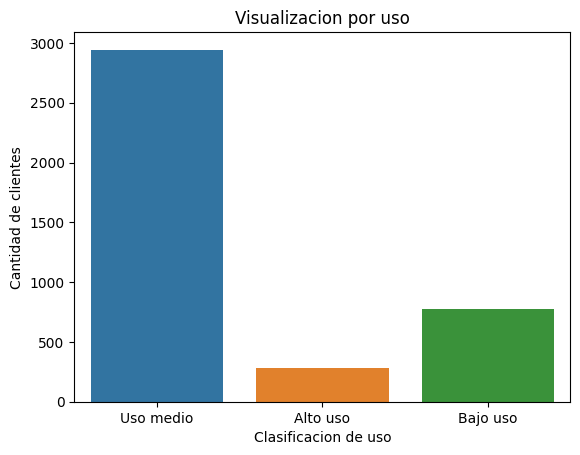

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title("Visualizacion por uso")
plt.xlabel("Clasificacion de uso")
plt.ylabel("Cantidad de clientes")

plt.show()


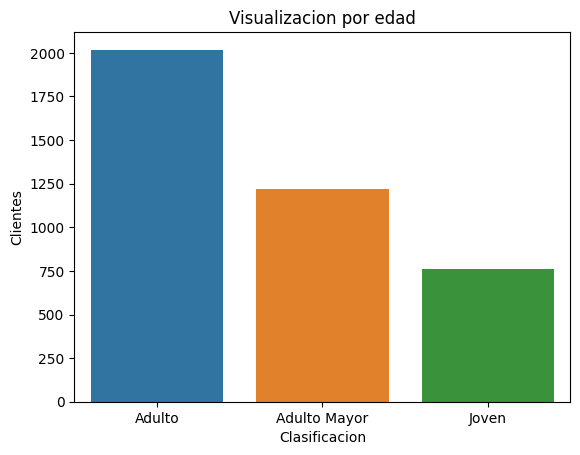

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title("Visualizacion por edad")
plt.xlabel("Clasificacion")
plt.ylabel("Clientes")

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron datos faltantes tanto en users, ejemplos son churn_date con 88,35%, city con 11.72%, en usage se encontro alto nivel de nulos en length y duration con 44.74% y 55.19% respectivamente.
- Se detectaron registros incorrectos en columnas relevantes como -999 en age.
- Se detectaron en city registros con "?".

🔍 **Segmentos por Edad**
- Se identificaron tres segmentos de clientes por edad, donde se puede concluir que en su mayoria se compone de adultos y adultos mayores, por tanto clientes maduros.

📊 **Segmentos por Nivel de Uso**
- Se puede interpretar en base a la clasificacion por nivel de uso, que la mayoria de los clientes se concentran en el uso medio y notoriamente un escaso grupo en el uso alto.

➡️ Esto sugiere que:
- Como conclusion general al analizar ambos segmentos edad y nivel de uso, se puede definir que la mayoria de los clientes son adultos con un uso medio y estable del servicio (clientes fieles).

💡 **Recomendaciones**
- Como recomendacion general, mantener al grupo adulto y fiel al servicio, pero ademas tratar de llegar a los clientes de alto uso y sin lugar a dudas realizar campañas para atraer a jovenes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`